# B-3001 · Rediseño de features (modelo jerárquico despivotado)

Reemplaza al esquema ancho `timestamp | P1 CONV | P1 CTRL | …` por un **despivot** que
convierte cada lectura en una fila y expone la jerarquía física del horno:

```
Nivel 0 · Horno       B-3001
    │
Nivel 1 · Timestamp   grilla horaria continua
    │
Nivel 2 · Paso        P1 · P2 · P3 · P4
    │
Nivel 3 · Tubo        17/18/31/32 × A–F   (6 termopares por paso, 24 en total)
    │
Nivel 4 · Temperatura  °C
```

Sobre esa tabla larga se construyen **tres bloques de features**, uno por nivel de agregación.
Cada bloque responde a una pregunta distinta:

| Nivel | Pregunta | Features |
|---|---|---|
| **1 · Tubo** | ¿este tubo se está degradando? | `slope`, `delta`, `exposure`, `thermal_dose`, `rank`, `persistence` |
| **2 · Paso** | ¿este paso está desbalanceado? | `mean`, `max`, `p95`, `std`, `spread`, `cv`, `hot_tube`, `hot_tube_slope`, `n_hot_tubes` |
| **3 · Horno** | ¿el horno como sistema está estable? | `global_max`, `global_p95`, `pass_gradient`, `critical_pass`, `critical_pass_persistence`, `global_thermal_dose`, `global_slope`, `global_instability` |

**Qué cambia respecto del notebook anterior**

1. La unidad de observación es `(timestamp, tubo)` explícita, con `paso` y `horno` como
   niveles reales y no como prefijo del nombre de columna. El identificador del tubo pasa a
   ser `17A … 32F` en vez de `"P1 T1 SP"`.
2. Se agrega una **capa de validez de sensor**: un termopar que marca <300 °C con el horno
   encendido está fallado, no frío. Sin este filtro el `spread` de un paso llega a 350 °C y
   arruina `mean`, `std` y `cv` (caso real: el tubo **18A** desde abril-2025).
3. Las features de contexto (`conv`, `ctrl`) bajan al nivel que les corresponde (paso) en vez
   de repetirse en cada fila de tubo.
4. Las salidas son **cuatro tablas**, una por nivel, más el panel unido para modelar.

**Orden de ejecución:** celdas 1 → 15, en secuencia. Pico de RAM ~3 GB, ~1 min con caché.

## 1. Entorno

In [2]:
import importlib, subprocess, sys
for pkg in ["pyarrow", "openpyxl"]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 60)

# Paleta de figuras: 4 hues categóricos (uno por paso) + diverging azul-gris-rojo.
# Orden fijo, nunca ciclado; las líneas van rotuladas para no depender solo del color.
COLOR_PASO = {"P1": "#2a78d6", "P2": "#eb6834", "P3": "#1baf7a", "P4": "#eda100"}
SUP, TINTA, TINTA2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e1e0d9"
CMAP_DIV = LinearSegmentedColormap.from_list(
    "div", ["#0d366b", "#2a78d6", "#9ec5f4", "#f0efec", "#e8a3a3", "#d03b3b", "#7d1f1f"])
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "figure.facecolor": SUP, "axes.facecolor": SUP,
    "text.color": TINTA, "axes.labelcolor": TINTA2, "xtick.color": TINTA2,
    "ytick.color": TINTA2, "axes.edgecolor": "#c3c2b7",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.1


## 2. Rutas

Se reutiliza el caché de la limpieza (`data/cache_*.parquet`). Si no existe, la celda 4 lee el
Excel y lo genera.

In [3]:
from pathlib import Path

BASE     = Path.cwd()
DATA     = BASE / "data"
FEATURES = BASE / "features"
REPORTES = BASE / "reportes"
for d in (DATA, FEATURES, REPORTES):
    d.mkdir(parents=True, exist_ok=True)

XLSX      = DATA / "Dataset_T°C_B-3001.xlsx"
CACHE_VAL = DATA / "cache_vals.parquet"
CACHE_SAT = DATA / "cache_sat.parquet"

OUT_LARGO = FEATURES / "b3001_largo.parquet"       # Nivel 3-4: el despivot crudo
OUT_TUBO  = FEATURES / "b3001_nivel1_tubo.parquet"
OUT_PASO  = FEATURES / "b3001_nivel2_paso.parquet"
OUT_HORNO = FEATURES / "b3001_nivel3_horno.parquet"
OUT_PANEL = FEATURES / "b3001_panel.parquet"       # los tres niveles unidos
OUT_DICC  = REPORTES / "diccionario_features.csv"
OUT_CORR  = REPORTES / "correlaciones_features_v2.csv"
OUT_STOPS = REPORTES / "detenciones.csv"

assert XLSX.exists() or CACHE_VAL.exists(), f"Falta {XLSX} y no hay caché en {DATA}."
print("Proyecto:", BASE)

Proyecto: /Users/bencourtin/Developer/projects/Tesis_HornoB3001


## 3. Configuración

Tres bloques: limpieza/validez, creep (T9 · API 530) y los umbrales de las features.

**Derivación del identificador de tubo.** El tag `TI_30017A.pv` codifica banco `17` +
posición `A`; el banco determina el paso. Los tubos rotulados `P1.1`/`P2.1` en el archivo
original son en realidad **P3 / P4**, ya corregido en el mapeo.

In [4]:
# ---------- limpieza, estado de operación y validez de sensor ----------
SAT_LIMITE   = 700.0     # >700 °C = clamp del historiador, no es medición
T_MIN_TUBO   = 300.0     # con el horno encendido, un tubo por debajo de esto = sensor fallado
RUN_TH       = 250.0     # mediana CONV >= 250 °C -> operación
STOP_TH      = 150.0     # mediana CONV <  150 °C -> detención fría
GAP_CIERRE_H = 6         # huecos <=6 h dentro de un STOP se cierran
MERGE_H      = 24        # detenciones separadas <24 h se fusionan
MIN_STOP_H   = 4         # mínimo de horas frías reales para contar el episodio
W_FLAT, TOL_FLAT = 12, 0.05   # std móvil 12 h < 0.05 °C -> lectura congelada

# ---------- creep: material T9, API 530 ----------
CLM               = 20.946
TMT_DISENO        = 705.0
DO, T_PROM        = 108.0, 12.1
P_MPA             = 57.2 * 0.0981
VIDA_DISENO_H     = 100_000.0
SIGMA_H   = (P_MPA * (DO - T_PROM)) / (2 * T_PROM)
LMP_SIGMA = (TMT_DISENO + 273.15) * (CLM + np.log10(VIDA_DISENO_H)) / 1000

# ---------- umbrales y ventanas de las features ----------
T_HOT     = 650.0        # tubo caliente. ~P95 de las lecturas en operación
W_SLOPE   = 6            # ventana de la pendiente corta (h)
W_DIA     = 24
W_MES     = 24 * 30
MIN_TUBOS = 3            # mínimo de tubos válidos para agregar un paso
H_TARGET  = 24           # horizonte de predicción (h)

# ---------- mapeo tag -> (paso, punto) ----------
MAPPING = {
 "TI_30021.pv":("P1","CONV"),
 "TI_30017A.pv":("P1","T1 SP"), "TI_30017D.pv":("P1","T1 SO"),
 "TI_30017B.pv":("P1","T5 SP"), "TI_30017E.pv":("P1","T5 SO"),
 "TI_30017C.pv":("P1","T10 NP"),"TI_30017F.pv":("P1","T10 NO"),
 "TI_30022.pv":("P2","CONV"),
 "TI_30018A.pv":("P2","T1 NP"), "TI_30018D.pv":("P2","T1 NO"),
 "TI_30018B.pv":("P2","T5 NP"), "TI_30018E.pv":("P2","T5 NO"),
 "TI_30018C.pv":("P2","T10 SP"),"TI_30018F.pv":("P2","T10 SO"),
 "TI_30033.pv":("P3","CONV"),
 "TI_30031A.pv":("P3","T1 SP"), "TI_30031D.pv":("P3","T1 SO"),
 "TI_30031B.pv":("P3","T5 SP"), "TI_30031E.pv":("P3","T5 SO"),
 "TI_30031C.pv":("P3","T10 NP"),"TI_30031F.pv":("P3","T10 NO"),
 "TI_30034.pv":("P4","CONV"),
 "TI_30032A.pv":("P4","T1 NP"), "TI_30032D.pv":("P4","T1 NO"),
 "TI_30032B.pv":("P4","T5 NP"), "TI_30032E.pv":("P4","T5 NO"),
 "TI_30032C.pv":("P4","T10 SP"),"TI_30032F.pv":("P4","T10 SO"),
 "TC_30028.pv":("CTRL","P4"), "TC_30027.pv":("CTRL","P3"),
 "TC_30020.pv":("CTRL","P2"), "TC_30019.pv":("CTRL","P1"),
}
HORNO = "B-3001"
PASOS = ["P1", "P2", "P3", "P4"]
TAGS  = list(MAPPING)
CONV  = {p: [c for c,(pp,n) in MAPPING.items() if pp==p and n=="CONV"][0] for p in PASOS}
CTRL  = {v[1]: k for k,v in MAPPING.items() if v[0]=="CTRL"}

# tag -> tubo "17A" / paso / elevación / cara
TAG2TUBO, TUBO_PASO, TUBO_ELEV, TUBO_CARA = {}, {}, {}, {}
for tag, (p, n) in MAPPING.items():
    if p == "CTRL" or n == "CONV":
        continue
    t = f"{tag[6:8]}{tag[8]}"                 # TI_30017A.pv -> "17A"
    elev, cara = n.split()                    # "T1 SP" -> ("T1", "SP")
    TAG2TUBO[tag] = t
    TUBO_PASO[t], TUBO_ELEV[t], TUBO_CARA[t] = p, elev, cara

TUBO_TAGS  = list(TAG2TUBO)
TUBOS      = sorted(TAG2TUBO.values())
TUBOS_PASO = {p: [t for t in TUBOS if TUBO_PASO[t] == p] for p in PASOS}

# ---------- ventana de análisis ----------
# Todo se calcula sobre el histórico completo (las acumuladas de creep y las ventanas de 30 d
# necesitan el pasado); el recorte a DATA_START se aplica recién en la celda 11.
DATA_START = pd.Timestamp("2024-10-01")
DATA_END   = None

print(f"sigma_h = {SIGMA_H:.2f} MPa | LMP_sigma = {LMP_SIGMA:.4f}")
for p in PASOS:
    print(f"  {p}: {TUBOS_PASO[p]}")
print(f"Jerarquía: 1 horno · {len(PASOS)} pasos · {len(TUBOS)} tubos")
print(f"Ventana: {DATA_START.date()} -> {DATA_END.date() if DATA_END is not None else 'último dato'}")

sigma_h = 22.24 MPa | LMP_sigma = 25.3791
  P1: ['17A', '17B', '17C', '17D', '17E', '17F']
  P2: ['18A', '18B', '18C', '18D', '18E', '18F']
  P3: ['31A', '31B', '31C', '31D', '31E', '31F']
  P4: ['32A', '32B', '32C', '32D', '32E', '32F']
Jerarquía: 1 horno · 4 pasos · 24 tubos
Ventana: 2024-10-01 -> último dato


## 4. Carga y limpieza (con caché)

Etiquetas de texto del historiador → `NaN`; valores >700 °C → flag `sat` y `NaN` en la
temperatura; grilla horaria continua para que los huecos queden explícitos; timestamps
duplicados eliminados. El caché guarda el histórico **completo**.

In [5]:
def carga_y_limpieza(ruta_xlsx):
    df = pd.read_excel(ruta_xlsx, sheet_name=0, header=0)
    df = df.iloc[3:].rename(columns={"Unnamed: 0": "ts"})       # 3 filas de metadatos
    df["ts"] = pd.to_datetime(df["ts"], errors="coerce")
    df = (df.dropna(subset=["ts"])
            .drop_duplicates("ts", keep="first")
            .sort_values("ts").set_index("ts"))
    for c in TAGS:
        df[c] = pd.to_numeric(df[c], errors="coerce")            # texto -> NaN
    df  = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq="h"))
    sat = (df[TAGS] > SAT_LIMITE)
    return df[TAGS].where(~sat).astype("float32"), sat

if CACHE_VAL.exists() and CACHE_SAT.exists():
    vals = pd.read_parquet(CACHE_VAL)
    sat  = pd.read_parquet(CACHE_SAT).astype(bool)
    print("Caché cargado.")
else:
    vals, sat = carga_y_limpieza(XLSX)
    vals.to_parquet(CACHE_VAL); sat.to_parquet(CACHE_SAT)
    print("Excel procesado y cacheado en data/.")

print(f"Histórico: {vals.index.min()} -> {vals.index.max()}  ({len(vals):,} horas)")
print(f"Celdas saturadas (>{SAT_LIMITE:.0f} °C): {int(sat.values.sum()):,}")

Caché cargado.
Histórico: 2008-06-05 15:00:00 -> 2026-01-30 14:00:00  (154,752 horas)
Celdas saturadas (>700 °C): 95,443


## 5. Estado de operación y detenciones

El estado sale de la mediana de las cuatro CONV: se cierran huecos cortos y se fusionan
episodios separados por menos de 24 h para no contar dos veces el mismo evento. De acá salen
`run` (filtro obligatorio antes de modelar) y `h_desde_arranque` (posición en el ciclo
operativo), que el nivel 3 hereda.

In [6]:
def _episodios(mask, min_h=1):
    """Segmentos True contiguos -> [(inicio, fin, horas)]."""
    grp, out = (mask != mask.shift()).cumsum(), []
    for _, idx in mask.groupby(grp).groups.items():
        if mask.loc[idx].iloc[0] and len(idx) >= min_h:
            out.append((idx[0], idx[-1], len(idx)))
    return out

def estados_y_detenciones(vals):
    op_ref = vals[list(CONV.values())].median(axis=1)
    op_ref = op_ref.fillna(vals[TUBO_TAGS].median(axis=1))
    state  = pd.Series(np.where(op_ref >= RUN_TH, "RUN",
                       np.where(op_ref <  STOP_TH, "STOP", "TRANS")), index=vals.index)
    state[op_ref.isna()] = "NODATA"

    s   = (state == "STOP").astype(int)
    s2  = s.rolling(2*GAP_CIERRE_H + 1, center=True, min_periods=1).max().astype(bool)
    eps = [[a, b, (b-a).total_seconds()/3600 + 1, op_ref.loc[a:b].min()]
           for a, b, _ in _episodios(s2) if s.loc[a:b].sum() >= MIN_STOP_H]

    merged = []
    for e in sorted(eps):
        if merged and (e[0] - merged[-1][1]).total_seconds()/3600 < MERGE_H:
            merged[-1][1] = e[1]
            merged[-1][2] = (e[1] - merged[-1][0]).total_seconds()/3600 + 1
            merged[-1][3] = min(merged[-1][3], e[3])
        else:
            merged.append(e)

    stops = pd.DataFrame(merged, columns=["inicio", "fin", "horas", "t_min"])
    stops["dias"] = stops.horas / 24
    return op_ref, state, stops

op_ref, state, stops = estados_y_detenciones(vals)
stops.to_csv(OUT_STOPS, index=False)

run = (state == "RUN")
arranques = pd.Series(0, index=vals.index)
arranques.loc[stops["fin"]] = 1
h_desde_arranque = (vals.index.to_series()
                        .groupby(arranques.cumsum()).cumcount().astype("int32"))

print(f"Detenciones: {len(stops)} | disponibilidad RUN: {run.mean()*100:.1f}%")
stops.nlargest(4, "dias")[["inicio", "fin", "dias"]]

Detenciones: 32 | disponibilidad RUN: 89.1%


,inicio,fin,dias
22,2021-10-11 11:00:00,2022-01-10 04:00:00,90.750000
30,2025-04-02 13:00:00,2025-05-23 01:00:00,50.541667
3,2010-03-02 00:00:00,2010-04-19 07:00:00,48.333333
9,2012-08-02 17:00:00,2012-09-15 03:00:00,43.458333


## 6. Despivot · la tabla larga

El corazón del rediseño. La matriz ancha de 32 columnas de tags se convierte en una tabla
donde **una fila es una medición**: `horno · ts · fecha · hora · paso · tubo · temperatura`.
Las CONV y las CTRL no son tubos y no entran acá: son atributos del paso y se incorporan en
el nivel 2.

Junto con la temperatura se despivotan cuatro banderas por lectura, que definen si el dato
sirve:

| Bandera | Significado |
|---|---|
| `run` | el horno estaba en operación en ese timestamp |
| `sat` | lectura >700 °C, clampeada por el historiador (temperatura real desconocida) |
| `sensor_frio` | <300 °C con el horno encendido → **termopar fallado**, no tubo frío |
| `sensor_flat` | std móvil de 12 h < 0.05 °C en operación → lectura congelada |

`valido = temperatura presente y no sensor_frio`. **Todas las features del resto del notebook
se calculan sobre la temperatura validada**, así un termopar suelto no se propaga como si
fuera física del proceso.

In [7]:
def despivotar(vals, sat, state, h_desde_arranque):
    """Matriz ancha de tags -> tabla larga (ts, tubo) con banderas de validez."""
    T = vals[TUBO_TAGS].rename(columns=TAG2TUBO)[TUBOS].astype("float32")
    S = sat[TUBO_TAGS].rename(columns=TAG2TUBO)[TUBOS]
    R = pd.DataFrame(np.repeat((state == "RUN").to_numpy()[:, None], len(TUBOS), axis=1),
                     index=T.index, columns=TUBOS)

    frio  = R & (T < T_MIN_TUBO)                                   # sensor fallado
    flat  = R & (T.rolling(W_FLAT).std() < TOL_FLAT)               # lectura congelada
    valid = T.notna() & ~frio

    piezas = {"temperatura": T,        "run": R.astype("int8"),
              "sat": S.astype("int8"), "sensor_frio": frio.astype("int8"),
              "sensor_flat": flat.astype("int8"), "valido": valid.astype("int8")}
    largo = pd.concat({k: v.stack() for k, v in piezas.items()}, axis=1)
    largo.index.names = ["ts", "tubo"]
    largo = largo.reset_index()

    largo["horno"] = HORNO
    largo["paso"]  = largo["tubo"].map(TUBO_PASO)
    largo["elev"]  = largo["tubo"].map(TUBO_ELEV)
    largo["cara"]  = largo["tubo"].map(TUBO_CARA)
    largo["fecha"] = largo["ts"].dt.normalize()
    largo["hora"]  = largo["ts"].dt.hour.astype("int8")
    largo["h_desde_arranque"] = largo["ts"].map(h_desde_arranque)

    for c in ("horno", "paso", "tubo", "elev", "cara"):
        largo[c] = largo[c].astype("category")

    return largo[["horno", "ts", "fecha", "hora", "paso", "tubo", "elev", "cara",
                  "temperatura", "valido", "run", "sat", "sensor_frio", "sensor_flat",
                  "h_desde_arranque"]]

largo = despivotar(vals, sat, state, h_desde_arranque)

print(f"Despivot: {largo.shape[0]:,} filas x {largo.shape[1]} columnas "
      f"({largo.memory_usage(deep=True).sum()/1e6:.0f} MB)")
assert len(largo) == len(vals) * len(TUBOS), "El despivot perdió o duplicó filas"
print(f"Jerarquía -> horno {largo.horno.nunique()} · pasos {largo.paso.nunique()} "
      f"· tubos {largo.tubo.nunique()} · timestamps {largo.ts.nunique():,}")

en_op = largo[largo.run == 1]
print(f"\nLecturas en operación: {len(en_op):,}")
print(f"  válidas       : {en_op.valido.mean()*100:5.1f}%")
print(f"  sensor_frio   : {en_op.sensor_frio.mean()*100:5.1f}%")
print(f"  sensor_flat   : {en_op.sensor_flat.mean()*100:5.1f}%")
print(f"  saturadas     : {en_op.sat.mean()*100:5.1f}%")
largo.head(8)

Despivot: 3,714,048 filas x 15 columnas (130 MB)
Jerarquía -> horno 1 · pasos 4 · tubos 24 · timestamps 154,752

Lecturas en operación: 3,308,064
  válidas       :  90.6%
  sensor_frio   :   1.7%
  sensor_flat   :   0.0%
  saturadas     :   2.7%


,horno,ts,fecha,hora,paso,tubo,elev,cara,temperatura,valido,run,sat,sensor_frio,sensor_flat,h_desde_arranque
0,B-3001,2008-06-05 15:00:00,2008-06-05,15,P1,17A,T1,SP,363.650085,1,1,0,0,0,0
1,B-3001,2008-06-05 15:00:00,2008-06-05,15,P1,17B,T5,SP,377.666840,1,1,0,0,0,0
2,B-3001,2008-06-05 15:00:00,2008-06-05,15,P1,17C,T10,NP,400.044281,1,1,0,0,0,0
3,B-3001,2008-06-05 15:00:00,2008-06-05,15,P1,17D,T1,SO,355.366028,1,1,0,0,0,0
4,B-3001,2008-06-05 15:00:00,2008-06-05,15,P1,17E,T5,SO,379.216278,1,1,0,0,0,0
5,B-3001,2008-06-05 15:00:00,2008-06-05,15,P1,17F,T10,NO,375.785278,1,1,0,0,0,0
6,B-3001,2008-06-05 15:00:00,2008-06-05,15,P2,18A,T1,NP,440.014191,1,1,0,0,0,0
7,B-3001,2008-06-05 15:00:00,2008-06-05,15,P2,18B,T5,NP,439.880219,1,1,0,0,0,0


### 6.1 Sensores con más lecturas descartadas

Chequeo de que el filtro golpea a los termopares que efectivamente fallaron y no a un paso
completo (eso último sería una ventana real de operación fría, no un problema de sensor).

In [8]:
diag = (largo[(largo.run == 1) & (largo.ts >= DATA_START)]
        .groupby("tubo", observed=True)
        .agg(horas_run=("run", "size"),
             pct_frio=("sensor_frio", lambda s: s.mean()*100),
             pct_flat=("sensor_flat", lambda s: s.mean()*100),
             pct_nan=("temperatura", lambda s: s.isna().mean()*100))
        .round(1).sort_values("pct_frio", ascending=False))
diag["paso"] = [TUBO_PASO[t] for t in diag.index]
print(diag.head(8).to_string())
print("\nSi un tubo supera ~30% de sensor_frio, tratarlo como fuera de servicio en el período.")

      horas_run  pct_frio  pct_flat    pct_nan paso
tubo                                               
18A        9813      44.5       0.0   0.000000   P2
17A        9813       2.4       0.0   0.100000   P1
17C        9813       2.0       0.0  12.900000   P1
17B        9813       1.7       0.0  42.700001   P1
17D        9813       1.5       0.0   0.000000   P1
18C        9813       1.4       0.0   0.100000   P2
17E        9813       1.3       0.0   0.100000   P1
18B        9813       1.2       0.0  41.599998   P2

Si un tubo supera ~30% de sensor_frio, tratarlo como fuera de servicio en el período.


## 7. De la tabla larga a la matriz · helpers

Las features de nivel 1 son operaciones sobre el eje del tiempo *dentro* de cada tubo, y las
de nivel 2 y 3 son operaciones *entre* tubos en el mismo timestamp. Ambas se calculan mucho
más rápido sobre la matriz `ts × tubo` que sobre 3,7 M de filas agrupadas.

Así que se pivotea de vuelta: **la tabla larga es la fuente de verdad, la matriz es solo el
motor de cálculo**. Todo lo que se calcula acá se devuelve al formato largo en la celda 11.

Los tres helpers y sus tests:

- `pendiente(df, w)` — pendiente OLS móvil en °C/h, resuelta con la forma cerrada
  $b=\frac{n\sum xy-\sum x\sum y}{n\sum x^2-(\sum x)^2}$ sobre sumas móviles, así que ignora
  los NaN sin recurrir a `rolling.apply` (que sería ~100× más lento).
- `racha(flag)` — horas consecutivas con la bandera activa, vectorizado por columna.
- `idxmax_seguro(df)` — `idxmax` por fila que devuelve `NaN` en vez de explotar cuando la
  fila entera es NaN (pasa cuando ningún sensor del paso reporta).

In [9]:
def a_matriz(largo, col):
    """Tabla larga -> matriz ts x tubo, con las columnas en orden fijo."""
    return largo.pivot(index="ts", columns="tubo", values=col).reindex(columns=TUBOS)

TT   = a_matriz(largo, "temperatura")
VAL  = a_matriz(largo, "valido").astype(bool)
RUNM = a_matriz(largo, "run").astype(bool)
SATM = a_matriz(largo, "sat").astype(bool)
T    = TT.where(VAL)                      # temperatura validada: base de todas las features
IDX  = T.index

def pendiente(df, w, mp=None):
    """Pendiente OLS móvil (°C/h) columna a columna, robusta a NaN."""
    mp  = mp or max(3, w // 2)
    y   = df.astype("float64")
    m   = y.notna()
    xv  = np.arange(len(df), dtype="float64") - len(df) / 2
    x   = pd.DataFrame(np.repeat(xv[:, None], y.shape[1], axis=1),
                       index=y.index, columns=y.columns).where(m)
    n   = m.rolling(w, min_periods=mp).sum()
    Sx  = x.rolling(w, min_periods=mp).sum()
    Sy  = y.rolling(w, min_periods=mp).sum()
    Sxx = (x * x).rolling(w, min_periods=mp).sum()
    Sxy = (x * y).rolling(w, min_periods=mp).sum()
    den = (n * Sxx - Sx**2).where(lambda d: d > 1e-9)
    return ((n * Sxy - Sx * Sy) / den).astype("float32")

def racha(flag):
    """Horas consecutivas con flag True, terminando en cada fila."""
    h    = flag.fillna(False).astype("int32")
    c    = h.cumsum()
    base = c.where(h == 0).ffill().fillna(0)
    return ((c - base) * h).astype("int32")

def idxmax_seguro(df):
    """idxmax por fila; NaN cuando la fila es enteramente NaN."""
    a     = df.to_numpy(dtype="float64")
    vacio = np.isnan(a).all(axis=1)
    pos   = np.argmax(np.where(np.isnan(a), -np.inf, a), axis=1)
    out   = np.asarray(df.columns, dtype=object)[pos]
    out[vacio] = None
    return pd.Series(out, index=df.index)

def t_ruptura(T_c):
    """t_r(T) a sigma_h por Larson-Miller, anclado a 705 °C / 100.000 h (API 530, SI)."""
    return 10 ** (LMP_SIGMA * 1000 / (np.asarray(T_c, dtype="float64") + 273.15) - CLM)

# --- tests de los helpers ---
_i = pd.date_range("2024-01-01", periods=30, freq="h")
_a = pd.Series(np.arange(30) * 2.0, index=_i)             # +2.0 °C/h exactos
_b = pd.Series(500 - np.arange(30) * 0.5, index=_i)       # -0.5 °C/h exactos
_b.iloc[10:13] = np.nan                                   # con hueco de sensor
_s = pendiente(pd.DataFrame({"a": _a, "b": _b}), 6)
assert np.isclose(_s["a"].iloc[-1], 2.0, atol=1e-4) and np.isclose(_s["b"].iloc[-1], -0.5, atol=1e-4)
assert np.isclose(_s["b"].iloc[13], -0.5, atol=1e-4)      # sobrevive al hueco
assert racha(pd.DataFrame({"a": [0,1,1,1,0,1,0,0,1,1]}).astype(bool))["a"].tolist() == \
       [0,1,2,3,0,1,0,0,1,2]
_m = idxmax_seguro(pd.DataFrame({"a": [1, np.nan], "b": [2, np.nan]}))
assert _m.iloc[0] == "b" and pd.isna(_m.iloc[1])
print("helpers OK | matriz:", T.shape, "| t_r(650 °C) =", f"{t_ruptura(650.0):,.0f} h")

helpers OK | matriz: (154752, 24) | t_r(650 °C) = 3,514,203 h


## 8. Nivel 1 · Tubo

Seis familias, una por pregunta sobre el tubo individual.

| Feature | Definición | Unidad | Para qué |
|---|---|---|---|
| `slope` | pendiente OLS de 6 h | °C/h | ¿se está calentando ahora? Detecta rampas y coquización incipiente |
| `slope_24h` | pendiente OLS de 24 h | °C/h | tendencia sostenida, filtra el ruido de control |
| `delta` | `T − mediana(paso)` | °C | desvío contra sus hermanos del mismo paso: aísla el tubo del modo común del horno |
| `delta_24h` | media móvil 24 h de `delta` | °C | ¿el desvío es un pico o se instaló? |
| `delta_z_30d` | z de `delta` contra su propia mediana/desvío de 30 d | – | **la señal de anomalía**: descuenta el offset estructural del punto de medición |
| `anomalia` | `\|delta_z_30d\| > 4` en operación | 0/1 | etiqueta para el criterio de detección de anomalías |
| `exposure` | horas acumuladas ≥650 °C en operación | h | tiempo total en régimen de fluencia acelerada |
| `exposure_30d` / `_frac_30d` | ídem en los últimos 30 d / normalizado por horas válidas | h, – | exposición reciente, comparable entre tubos con distinta cobertura de sensor |
| `thermal_dose_1h` | `1 / t_ruptura(T)` (Larson-Miller) | 1/h | daño por fluencia de esta hora |
| `thermal_dose` | suma acumulada de lo anterior (Robinson) | – | fracción de vida consumida, 0→1 |
| `thermal_dose_30d` | daño acumulado en los últimos 30 d | – | ritmo actual de consumo de vida |
| `rank` | puesto por temperatura dentro del paso, 1 = el más caliente | 1–6 | posición relativa, invariante al nivel térmico global |
| `rank_horno` | ídem contra los 24 tubos | 1–24 | criticidad absoluta dentro del horno |
| `persistence` | horas consecutivas con `T ≥ 650 °C` | h | distingue un pico transitorio de una condición instalada |
| `persistence_rank1` | horas consecutivas siendo el más caliente del paso | h | identifica al tubo líder crónico |
| `sensor_health_30d` | fracción de horas de operación con lectura válida en 30 d | – | confianza del dato; evita leer una falla de sensor como una anomalía térmica |

`thermal_dose` es adimensional y **no se reinicia**: arrastra el daño desde 2008. `exposure`
también. Las dos son *estado*, no señal hora a hora — ver las notas del final.

La saturación se trata como cota inferior: si el historiador clampeó en 700 °C el tubo estaba
al menos a 700 °C, así que se acumula daño a esa temperatura en vez de acumular cero.

**Por qué `delta` no alcanza solo.** Los seis termopares de un paso están a distinta elevación
(T1 / T5 / T10) y en distinta cara, así que un tubo puede estar 40 °C por encima de la mediana
del paso de forma permanente y perfectamente sana: es su posición, no su condición. Por eso el
`delta` crudo viene acompañado de `delta_z_30d`, que lo normaliza contra la propia historia del
punto, y por eso `elev` y `cara` viajan como categóricas en la tabla.

In [10]:
# mediana del paso, difundida a cada tubo (el "modo común" que delta descuenta)
MED_PASO = pd.DataFrame({p: T[TUBOS_PASO[p]].median(axis=1) for p in PASOS})
MED_B    = MED_PASO[[TUBO_PASO[t] for t in TUBOS]]
MED_B.columns = TUBOS

n1  = {}
hot = (T >= T_HOT) & RUNM
rk  = pd.concat([T[TUBOS_PASO[p]].rank(axis=1, ascending=False, method="min")
                 for p in PASOS], axis=1)[TUBOS]

# --- dinámica ---
n1["slope"]     = pendiente(T, W_SLOPE)
n1["slope_24h"] = pendiente(T, W_DIA)

# --- desvío contra el paso ---
n1["delta"]     = (T - MED_B).astype("float32")
n1["delta_24h"] = n1["delta"].rolling(W_DIA, min_periods=W_DIA//2).mean().astype("float32")

# z de delta contra la propia historia del tubo: descuenta el offset estructural de la
# elevación del termopar, así "caliente para lo que es normal en ESTE punto" != "caliente"
_mu = n1["delta"].rolling(W_MES, min_periods=24*7).median()
_sd = n1["delta"].rolling(W_MES, min_periods=24*7).std()
n1["delta_z_30d"] = ((n1["delta"] - _mu) / _sd.where(_sd > 0.1)).astype("float32")
n1["anomalia"]    = ((n1["delta_z_30d"].abs() > 4) & RUNM & VAL).astype("int8")

# --- exposición ---
horas_run_30d = RUNM.rolling(W_MES, min_periods=W_DIA).sum()
horas_val_30d = (VAL & RUNM).rolling(W_MES, min_periods=W_DIA).sum()
n1["exposure"]          = hot.cumsum().astype("int32")
n1["exposure_30d"]      = hot.rolling(W_MES, min_periods=W_DIA).sum().astype("float32")
n1["exposure_frac_30d"] = (n1["exposure_30d"] / horas_val_30d.where(horas_val_30d > 0)).astype("float32")

# --- dosis térmica (creep, Robinson sobre Larson-Miller) ---
usable = T.notna() & RUNM
dose   = pd.DataFrame(0.0, index=IDX, columns=TUBOS)
dose   = dose.mask(usable, 1.0 / t_ruptura(T.where(usable)))
dose   = dose.mask(SATM & RUNM, 1.0 / t_ruptura(SAT_LIMITE))   # cota inferior en horas ciegas
dose   = dose.fillna(0.0)
n1["thermal_dose_1h"]  = dose.astype("float32")
n1["thermal_dose"]     = dose.cumsum().astype("float32")
n1["thermal_dose_30d"] = dose.rolling(W_MES, min_periods=W_DIA).sum().astype("float32")

# --- jerarquía relativa ---
n1["rank"]       = rk.astype("float32")
n1["rank_horno"] = T.rank(axis=1, ascending=False, method="min").astype("float32")

# --- persistencia ---
n1["hot"]               = hot.astype("int8")
n1["persistence"]       = racha(hot)
n1["persistence_rank1"] = racha(rk == 1)

# --- salud del sensor ---
n1["sensor_health_30d"] = (horas_val_30d / horas_run_30d.where(horas_run_30d > 0)).astype("float32")

print(f"Nivel 1: {len(n1)} features x {len(TUBOS)} tubos")
pd.DataFrame({k: v.loc[v.index >= DATA_START].stack().describe()
              for k, v in n1.items()}).T.round(3)

Nivel 1: 18 features x 24 tubos


,count,mean,std,min,25%,50%,75%,max
slope,213738.0,0.013,5.300,-115.841,-0.401,0.027,0.479,93.155
slope_24h,213984.0,0.016,2.565,-33.024,-0.106,0.027,0.171,42.349
delta,213050.0,-6.306,46.805,-345.281,-27.107,0.000,17.873,271.826
delta_24h,213984.0,-6.241,46.036,-318.500,-26.810,0.000,17.919,148.894
delta_z_30d,209318.0,0.042,1.561,-26.833,-0.696,0.000,0.813,26.833
anomalia,280296.0,0.011,0.106,0.000,0.000,0.000,0.000,1.000
exposure,280296.0,3115.511,4439.065,111.000,260.000,950.000,4852.000,18961.000
exposure_30d,280296.0,30.003,87.747,0.000,0.000,0.000,8.000,696.000
exposure_frac_30d,224056.0,0.077,0.191,0.000,0.000,0.000,0.021,1.000
thermal_dose_1h,280296.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000


## 9. Nivel 2 · Paso

Agrega los 6 tubos de cada paso en cada timestamp. Un paso solo se agrega si tiene al menos
`MIN_TUBOS = 3` lecturas válidas; con menos, el estadístico diría más sobre qué sensores
sobrevivieron que sobre el proceso.

| Feature | Definición | Para qué |
|---|---|---|
| `mean` | media de los tubos válidos | nivel térmico del paso |
| `max` | máximo | el punto que gobierna la falla |
| `p95` | percentil 95 entre tubos | máximo suavizado, menos sensible a un outlier |
| `std` | desvío estándar entre tubos | dispersión |
| `spread` | `max − min` | **desbalance de distribución de fuego o de flujo**: el síntoma clásico de coquización desigual |
| `cv` | `std / mean` | dispersión normalizada, comparable entre pasos a distinta temperatura |
| `hot_tube` | id del tubo más caliente | ¿quién manda? |
| `hot_tube_slope` | `slope` de ese tubo | ¿el líder térmico además está subiendo? |
| `n_hot_tubes` | cuántos tubos ≥650 °C | extensión del problema: 1 tubo es local, 4 es el paso entero |
| `n_tubos` | tubos válidos usados | denominador honesto de todo lo anterior |
| `conv` / `ctrl` | temperatura de convección y del lazo de control del paso | contexto de proceso |
| `delta_ctrl` | `mean − ctrl` | desvío del paso respecto de su setpoint efectivo |

**Advertencia sobre `p95`:** con 6 tubos (a veces 3-4 válidos) el percentil 95 interpolado
queda pegado al máximo. Se calcula porque estaba pedido y porque es consistente con
`global_p95`, pero como feature aporta poco por encima de `max`; en un modelo lineal conviene
elegir uno de los dos.

In [11]:
def stat_paso(fun):
    """Aplica fun a la submatriz de cada paso -> DataFrame ts x paso."""
    return pd.DataFrame({p: fun(T[TUBOS_PASO[p]]) for p in PASOS})

n_val  = stat_paso(lambda d: d.notna().sum(axis=1))
valido = n_val >= MIN_TUBOS                       # máscara de agregación confiable

n2 = {}
n2["mean"]   = stat_paso(lambda d: d.mean(axis=1)).where(valido)
n2["max"]    = stat_paso(lambda d: d.max(axis=1)).where(valido)
n2["min"]    = stat_paso(lambda d: d.min(axis=1)).where(valido)
n2["p95"]    = stat_paso(lambda d: d.quantile(0.95, axis=1)).where(valido)
n2["std"]    = stat_paso(lambda d: d.std(axis=1)).where(valido)
n2["spread"] = n2["max"] - n2["min"]
n2["cv"]     = n2["std"] / n2["mean"].abs()
n2["n_hot_tubes"] = stat_paso(lambda d: (d >= T_HOT).sum(axis=1)).where(valido).astype("float32")
n2["n_tubos"]     = n_val.astype("int8")

# tubo más caliente del paso y su pendiente (lookup posicional, sin loop por fila)
n2["hot_tube"] = stat_paso(idxmax_seguro).where(valido)
_sl  = n1["slope"].to_numpy()
_fil = np.arange(len(IDX))
n2["hot_tube_slope"] = pd.DataFrame(index=IDX, columns=PASOS, dtype="float32")
for p in PASOS:
    cod = pd.Categorical(n2["hot_tube"][p], categories=TUBOS).codes
    col = np.full(len(IDX), np.nan, dtype="float32")
    ok  = cod >= 0
    col[ok] = _sl[_fil[ok], cod[ok]]
    n2["hot_tube_slope"][p] = col

# contexto de proceso del paso
n2["conv"]       = pd.DataFrame({p: vals[CONV[p]] for p in PASOS}).reindex(IDX)
n2["ctrl"]       = pd.DataFrame({p: vals[CTRL[p]] for p in PASOS}).reindex(IDX)
n2["delta_ctrl"] = n2["mean"] - n2["ctrl"]

for k, v in n2.items():
    if v.dtypes.iloc[0].kind == "f":
        n2[k] = v.astype("float32")

print(f"Nivel 2: {len(n2)} features x {len(PASOS)} pasos")
print("\nÚltimo timestamp:")
pd.DataFrame({k: v.iloc[-1] for k, v in n2.items()}).T

Nivel 2: 14 features x 4 pasos

Último timestamp:


,P1,P2,P3,P4
mean,578.045776,559.620239,628.275269,592.75
max,620.130554,608.984131,690.762085,645.991821
min,508.228973,501.459625,550.19165,500.681793
p95,619.466797,608.120728,680.386536,643.241455
std,52.161026,48.505749,47.936512,64.665962
spread,111.901581,107.524506,140.570435,145.310028
cv,0.090237,0.086676,0.076299,0.109095
n_hot_tubes,0.0,0.0,1.0,0.0
n_tubos,4,5,6,4
hot_tube,17A,18D,31E,32B


## 10. Nivel 3 · Horno

Una fila por timestamp. Describe al B-3001 como sistema: no *qué tubo* está mal sino *si el
horno está operando de forma pareja y estable*.

| Feature | Definición | Para qué |
|---|---|---|
| `global_max` | máximo de los 24 tubos | el peor punto del horno |
| `global_p95` | percentil 95 de los 24 tubos | techo térmico robusto (acá sí hay muestra suficiente) |
| `global_mean` / `global_spread` | media y `max − min` | nivel y rango |
| `pass_gradient` | `max(mean_paso) − min(mean_paso)` | **desbalance entre pasos**: cuánto más cargado está un paso que otro. Es una falla de distribución, no de un tubo |
| `critical_pass` | paso con la mayor `mean` | dónde está el problema ahora |
| `critical_pass_persistence` | horas consecutivas que el mismo paso es el crítico | distingue rotación normal de un paso crónicamente sobrecargado |
| `global_thermal_dose` | media de `thermal_dose` de los 24 tubos | daño acumulado representativo del horno |
| `global_thermal_dose_max` | máximo | el tubo que fija la vida remanente del equipo |
| `global_slope` | pendiente 6 h de `global_mean` | ¿el horno entero se está calentando? Separa maniobra operativa de deriva de un tubo |
| `global_instability` | std móvil 24 h de `global_mean` | **volatilidad térmica**: control inestable, oscilación de fuego o de carga |
| `n_hot_tubes` | tubos ≥650 °C en todo el horno | extensión total |
| `run`, `h_desde_arranque` | estado y posición en el ciclo | contexto operativo |

`critical_pass` se define por la **media** del paso y no por su máximo: con 40-60 % de
cobertura de sensores en algunos tubos, el máximo salta de paso hora a hora y la
persistencia se vuelve ruido.

Ojo con la asimetría de escala: `global_slope` es la pendiente de la *media*, así que un solo
tubo disparándose casi no la mueve — para eso está `slope` del nivel 1. Son complementarias,
no redundantes.

In [12]:
g_mean = T.mean(axis=1)
g_max  = T.max(axis=1)
g_min  = T.min(axis=1)
crit   = idxmax_seguro(n2["mean"])
_chg   = (crit != crit.shift()).cumsum()

n3 = pd.DataFrame({
    "global_mean":               g_mean,
    "global_max":                g_max,
    "global_p95":                T.quantile(0.95, axis=1),
    "global_spread":             g_max - g_min,
    "pass_gradient":             n2["mean"].max(axis=1) - n2["mean"].min(axis=1),
    "critical_pass":             crit,
    "critical_pass_persistence": crit.groupby(_chg).cumcount().add(1).where(crit.notna()),
    "global_thermal_dose":       n1["thermal_dose"].mean(axis=1),
    "global_thermal_dose_max":   n1["thermal_dose"].max(axis=1),
    "global_slope":              pendiente(g_mean.to_frame("g"), W_SLOPE)["g"],
    "global_instability":        g_mean.rolling(W_DIA, min_periods=W_DIA//2).std(),
    "n_hot_tubes":               ((T >= T_HOT) & RUNM).sum(axis=1).where(T.notna().any(axis=1)),
    "n_tubos":                   T.notna().sum(axis=1).astype("int8"),
    "run":                       run.astype("int8").reindex(IDX),
    "h_desde_arranque":          h_desde_arranque.reindex(IDX),
})
for c in n3.select_dtypes("float64"):
    n3[c] = n3[c].astype("float32")

print(f"Nivel 3: {n3.shape[1]} features x {len(n3):,} timestamps")
n3[n3.run == 1].tail(3).T

Nivel 3: 15 features x 154,752 timestamps


ts,2026-01-30 12:00:00,2026-01-30 13:00:00,2026-01-30 14:00:00
global_mean,593.920898,593.228455,592.15448
global_max,695.397583,694.916443,690.762085
global_p95,655.82196,655.440186,653.410095
global_spread,194.977539,193.393921,190.080292
pass_gradient,70.649719,70.746155,68.655029
critical_pass,P3,P3,P3
critical_pass_persistence,95.0,96.0,97.0
global_thermal_dose,0.032431,0.032431,0.032432
global_thermal_dose_max,0.151502,0.151502,0.151502
global_slope,0.454667,0.397234,0.294179


## 11. Objetivos, recorte y ensamble del panel

Los objetivos son del nivel 1: se predice el tubo, no el horno.

- `target_T_24h` — temperatura del tubo a t+24 h (regresión)
- `target_delta_24h` — desvío contra el paso a t+24 h (regresión sobre la señal ya
  descontada del modo común; suele ser el objetivo más informativo)
- `target_hot_24h` — ¿estará ≥650 °C a t+24 h? (clasificación)
- `lag_24h` — temperatura hace 24 h. **No es una feature, es el baseline obligatorio**: la
  predicción de persistencia contra la que se mide cualquier modelo

Recién acá se recorta a `DATA_START`. Todo lo anterior corrió sobre el histórico completo,
así que las acumuladas arrastran el daño real desde 2008 y las ventanas de 24 h / 30 d llegan
calientes, sin NaN de arranque.

El panel une los tres niveles con prefijos `paso_` y `horno_`. Cada fila queda con su propia
temperatura, el estado de su paso y el estado del horno en ese instante — que es exactamente
la jerarquía del despivot, aplanada para el modelo.

In [13]:
# --- objetivos y baseline ---
tg = {
    "lag_24h":          T.shift(H_TARGET),
    "target_T_24h":     T.shift(-H_TARGET),
    "target_delta_24h": n1["delta"].shift(-H_TARGET),
    "target_hot_24h":   hot.astype("float32").shift(-H_TARGET),
}

# --- recorte a la ventana de análisis ---
msk = (IDX >= DATA_START) if DATA_END is None else ((IDX >= DATA_START) & (IDX <= DATA_END))
rec = lambda d: d.loc[msk]

# --- nivel 1 -> largo ---
nivel1 = pd.concat({k: rec(v).stack() for k, v in {**n1, **tg}.items()}, axis=1)
nivel1.index.names = ["ts", "tubo"]
nivel1 = nivel1.reset_index()

base = largo.loc[largo.ts >= DATA_START,
                 ["horno","ts","fecha","hora","paso","tubo","elev","cara",
                  "temperatura","valido","run","sat","sensor_frio","sensor_flat",
                  "h_desde_arranque"]]
if DATA_END is not None:
    base = base[base.ts <= DATA_END]
nivel1 = base.merge(nivel1, on=["ts", "tubo"], how="left")

# --- nivel 2 -> largo ---
nivel2 = pd.concat({k: rec(v).stack() for k, v in n2.items()}, axis=1)
nivel2.index.names = ["ts", "paso"]
nivel2 = nivel2.reset_index()

# --- nivel 3 -> largo ---
nivel3 = rec(n3).reset_index(names="ts")

# --- panel: los tres niveles unidos ---
panel = (nivel1
         .merge(nivel2.add_prefix("paso_").rename(columns={"paso_ts":"ts","paso_paso":"paso"}),
                on=["ts", "paso"], how="left")
         .merge(nivel3.drop(columns=["run","h_desde_arranque"])
                      .add_prefix("horno_").rename(columns={"horno_ts":"ts"}),
                on="ts", how="left"))
panel["paso"] = panel["paso"].astype("category")
panel["tubo"] = panel["tubo"].astype("category")

assert len(panel) == len(nivel1), "El join con paso/horno duplicó filas"
print(f"nivel1 (tubo)  : {nivel1.shape[0]:>9,} x {nivel1.shape[1]:>3}")
print(f"nivel2 (paso)  : {nivel2.shape[0]:>9,} x {nivel2.shape[1]:>3}")
print(f"nivel3 (horno) : {nivel3.shape[0]:>9,} x {nivel3.shape[1]:>3}")
print(f"panel          : {panel.shape[0]:>9,} x {panel.shape[1]:>3}  "
      f"({panel.memory_usage(deep=True).sum()/1e6:.0f} MB)")
print(f"Ventana: {panel.ts.min():%Y-%m-%d} -> {panel.ts.max():%Y-%m-%d}")
panel[(panel.run == 1) & (panel.valido == 1)].head(3).T

nivel1 (tubo)  :   280,296 x  37
nivel2 (paso)  :    46,716 x  16
nivel3 (horno) :    11,679 x  16
panel          :   280,296 x  64  (65 MB)
Ventana: 2024-10-01 -> 2026-01-30


,0,2,3
horno,B-3001,B-3001,B-3001
ts,2024-10-01 00:00:00,2024-10-01 00:00:00,2024-10-01 00:00:00
fecha,2024-10-01 00:00:00,2024-10-01 00:00:00,2024-10-01 00:00:00
hora,0,0,0
paso,P1,P1,P1
...,...,...,...
horno_global_thermal_dose_max,0.12098,0.12098,0.12098
horno_global_slope,1.168715,1.168715,1.168715
horno_global_instability,2.634573,2.634573,2.634573
horno_n_hot_tubes,0.0,0.0,0.0


## 12. Diccionario de datos

In [14]:
DICC = [
 # nivel, feature, unidad, definición
 ("0-4","horno","–","identificador del equipo (B-3001)"),
 ("0-4","ts / fecha / hora","–","timestamp horario, y su fecha y hora desagregadas"),
 ("0-4","paso","–","paso del horno: P1–P4"),
 ("0-4","tubo","–","termopar: banco (17/18/31/32) + posición (A–F)"),
 ("0-4","elev / cara","–","elevación (T1/T5/T10) y cara (SP/SO/NP/NO) del punto de medición"),
 ("0-4","temperatura","°C","TMT medida, ya validada (NaN si el sensor está fallado)"),
 ("0-4","valido","0/1","lectura presente y no descartada por sensor_frio"),
 ("0-4","run","0/1","horno en operación (mediana CONV ≥ 250 °C)"),
 ("0-4","sat","0/1","lectura clampeada en 700 °C por el historiador"),
 ("0-4","sensor_frio","0/1","<300 °C con el horno encendido: termopar fallado"),
 ("0-4","sensor_flat","0/1","std móvil 12 h < 0.05 °C en operación: lectura congelada"),
 ("0-4","h_desde_arranque","h","horas desde el fin de la última detención"),
 ("1","slope","°C/h","pendiente OLS móvil de 6 h"),
 ("1","slope_24h","°C/h","pendiente OLS móvil de 24 h"),
 ("1","delta","°C","T − mediana del paso: desvío contra sus hermanos"),
 ("1","delta_24h","°C","media móvil 24 h de delta"),
 ("1","delta_z_30d","–","z de delta contra su mediana/desvío móvil de 30 d: señal de anomalía"),
 ("1","anomalia","0/1","|delta_z_30d| > 4 en operación con lectura válida"),
 ("1","exposure","h","horas acumuladas ≥650 °C en operación (desde 2008)"),
 ("1","exposure_30d","h","ídem en los últimos 30 días"),
 ("1","exposure_frac_30d","–","exposure_30d / horas válidas en operación en 30 d"),
 ("1","thermal_dose_1h","1/h","daño por fluencia de la hora: 1/t_ruptura(T), Larson-Miller"),
 ("1","thermal_dose","–","suma de Robinson: fracción de vida consumida (0→1)"),
 ("1","thermal_dose_30d","–","daño acumulado en los últimos 30 días"),
 ("1","rank","1–6","puesto por temperatura dentro del paso (1 = más caliente)"),
 ("1","rank_horno","1–24","puesto por temperatura entre los 24 tubos"),
 ("1","hot","0/1","T ≥ 650 °C en operación"),
 ("1","persistence","h","horas consecutivas con hot = 1"),
 ("1","persistence_rank1","h","horas consecutivas siendo el más caliente del paso"),
 ("1","sensor_health_30d","–","fracción de horas de operación con lectura válida en 30 d"),
 ("1","lag_24h","°C","temperatura 24 h atrás: baseline de persistencia"),
 ("1","target_T_24h","°C","OBJETIVO · temperatura a t+24 h"),
 ("1","target_delta_24h","°C","OBJETIVO · delta a t+24 h"),
 ("1","target_hot_24h","0/1","OBJETIVO · hot a t+24 h"),
 ("2","paso_mean / max / min / p95","°C","estadísticos entre los tubos válidos del paso"),
 ("2","paso_std","°C","desvío estándar entre tubos del paso"),
 ("2","paso_spread","°C","max − min: desbalance de fuego o de flujo en el paso"),
 ("2","paso_cv","–","std / |mean|: dispersión normalizada"),
 ("2","paso_hot_tube","–","id del tubo más caliente del paso"),
 ("2","paso_hot_tube_slope","°C/h","pendiente de 6 h de ese tubo"),
 ("2","paso_n_hot_tubes","0–6","tubos del paso con T ≥ 650 °C"),
 ("2","paso_n_tubos","0–6","tubos con lectura válida (denominador de los estadísticos)"),
 ("2","paso_conv / paso_ctrl","°C","convección y lazo de control del paso"),
 ("2","paso_delta_ctrl","°C","mean del paso − ctrl: desvío respecto del setpoint efectivo"),
 ("3","horno_global_mean / max / p95","°C","estadísticos entre los 24 tubos"),
 ("3","horno_global_spread","°C","max − min del horno completo"),
 ("3","horno_pass_gradient","°C","max − min de las medias de paso: desbalance entre pasos"),
 ("3","horno_critical_pass","–","paso con la media más alta"),
 ("3","horno_critical_pass_persistence","h","horas consecutivas del mismo paso como crítico"),
 ("3","horno_global_thermal_dose","–","media de thermal_dose de los 24 tubos"),
 ("3","horno_global_thermal_dose_max","–","máximo de thermal_dose: fija la vida remanente"),
 ("3","horno_global_slope","°C/h","pendiente 6 h de global_mean"),
 ("3","horno_global_instability","°C","std móvil 24 h de global_mean: volatilidad térmica"),
 ("3","horno_n_hot_tubes","0–24","tubos ≥650 °C en todo el horno"),
]
dicc = pd.DataFrame(DICC, columns=["nivel", "feature", "unidad", "definicion"])
dicc.to_csv(OUT_DICC, index=False)
print(f"Guardado: {OUT_DICC.name} ({len(dicc)} entradas)")
dicc

Guardado: diccionario_features.csv (54 entradas)


,nivel,feature,unidad,definicion
0,0-4,horno,–,identificador del equipo (B-3001)
1,0-4,ts / fecha / hora,–,"timestamp horario, y su fecha y hora desagregadas"
2,0-4,paso,–,paso del horno: P1–P4
3,0-4,tubo,–,termopar: banco (17/18/31/32) + posición (A–F)
4,0-4,elev / cara,–,elevación (T1/T5/T10) y cara (SP/SO/NP/NO) del...
5,0-4,temperatura,°C,"TMT medida, ya validada (NaN si el sensor está..."
6,0-4,valido,0/1,lectura presente y no descartada por sensor_frio
7,0-4,run,0/1,horno en operación (mediana CONV ≥ 250 °C)
8,0-4,sat,0/1,lectura clampeada en 700 °C por el historiador
9,0-4,sensor_frio,0/1,<300 °C con el horno encendido: termopar fallado


## 13. Validación

Chequeos de integridad de la jerarquía, de rango físico y de coherencia entre niveles. Si
alguno falla, revisar la celda correspondiente antes de modelar.

In [15]:
r = panel[(panel.run == 1) & (panel.valido == 1)]

# --- integridad de la jerarquía ---
assert panel.groupby("ts", observed=True).size().eq(len(TUBOS)).all(), "Faltan tubos en algún timestamp"
assert not panel.duplicated(["ts", "tubo"]).any(), "Clave (ts, tubo) duplicada"
assert panel.groupby("paso", observed=True).tubo.nunique().eq(6).all(), "Un paso no tiene 6 tubos"

# --- rango físico ---
assert panel.temperatura.max() <= SAT_LIMITE, "Temperaturas >700 °C sin filtrar"
assert r.temperatura.min() >= T_MIN_TUBO, "Lecturas de sensor fallado sobrevivieron al filtro"
assert panel.thermal_dose.max() < 1, "thermal_dose ≥ 1: revisar el modelo de creep"
assert r["rank"].between(1, 6).all() and r.rank_horno.between(1, 24).all(), "Rangos fuera de escala"
assert (panel.persistence >= 0).all(), "persistence negativa"

# --- coherencia entre niveles ---
chk = r.groupby("ts", observed=True).agg(tmax=("temperatura","max"), gmax=("horno_global_max","first"))
assert np.allclose(chk.tmax, chk.gmax, atol=0.01), "global_max no coincide con el máximo de los tubos"
chk2 = (r.groupby(["ts","paso"], observed=True)
          .agg(tmax=("temperatura","max"), pmax=("paso_max","first")).dropna())
assert np.allclose(chk2.tmax, chk2.pmax, atol=0.01), "paso_max no coincide con el máximo del paso"

print("Todos los chequeos pasaron.\n")
print(f"Ventana        : {panel.ts.min():%Y-%m-%d} -> {panel.ts.max():%Y-%m-%d}")
print(f"Filas          : {len(panel):,}  ({panel.ts.nunique():,} h x {len(TUBOS)} tubos)")
print(f"Filas usables  : {len(r):,} ({len(r)/len(panel)*100:.1f}% — RUN y sensor válido)")
print(f"TMT en operación -> P50 {r.temperatura.median():.0f} °C | "
      f"P95 {r.temperatura.quantile(.95):.0f} °C | max {r.temperatura.max():.0f} °C")
print(f"paso_spread      -> P50 {r.paso_spread.median():.0f} °C | P95 {r.paso_spread.quantile(.95):.0f} °C")
print(f"pass_gradient    -> P50 {r.horno_pass_gradient.median():.0f} °C | "
      f"P95 {r.horno_pass_gradient.quantile(.95):.0f} °C")

print("\nTop 5 tubos por daño acumulado (Robinson):")
print(panel.groupby("tubo", observed=True)
           .agg(paso=("paso","first"), thermal_dose=("thermal_dose","max"),
                exposure_h=("exposure","max"), horas_hot=("hot","sum"))
           .nlargest(5, "thermal_dose").round(4).to_string())

print("\nCriticidad por paso (horas como critical_pass en la ventana):")
print(nivel3[nivel3.run == 1].critical_pass.value_counts().to_string())

Todos los chequeos pasaron.

Ventana        : 2024-10-01 -> 2026-01-30
Filas          : 280,296  (11,679 h x 24 tubos)
Filas usables  : 181,989 (64.9% — RUN y sensor válido)
TMT en operación -> P50 559 °C | P95 655 °C | max 700 °C
paso_spread      -> P50 112 °C | P95 203 °C
pass_gradient    -> P50 59 °C | P95 113 °C

Top 5 tubos por daño acumulado (Robinson):
     paso  thermal_dose  exposure_h  horas_hot
tubo                                          
18D    P2        0.1515       12565       1069
31B    P3        0.1281        1776       1078
18B    P2        0.1158         654        417
17C    P1        0.1088         637         25
18F    P2        0.0982         185         32

Criticidad por paso (horas como critical_pass en la ventana):
critical_pass
P4    5271
P3    1891
P1    1832
P2     792


## 14. Figuras

Dos diagnósticos: la jerarquía en acción y la matriz de correlaciones entre features.

**Cómo leer la fila de `target_hot_24h`.** Es binaria, así que su correlación de Spearman con
una feature continua es en realidad una **rank-biserial**: mide cuánto separa la feature a las
dos clases, no asociación monótona entre dos continuas. Con 6,5 % de prevalencia las
magnitudes salen atenuadas y **no son comparables de igual a igual** con el resto de la
matriz — se leen entre sí, por orden, no contra las filas de los targets de regresión.

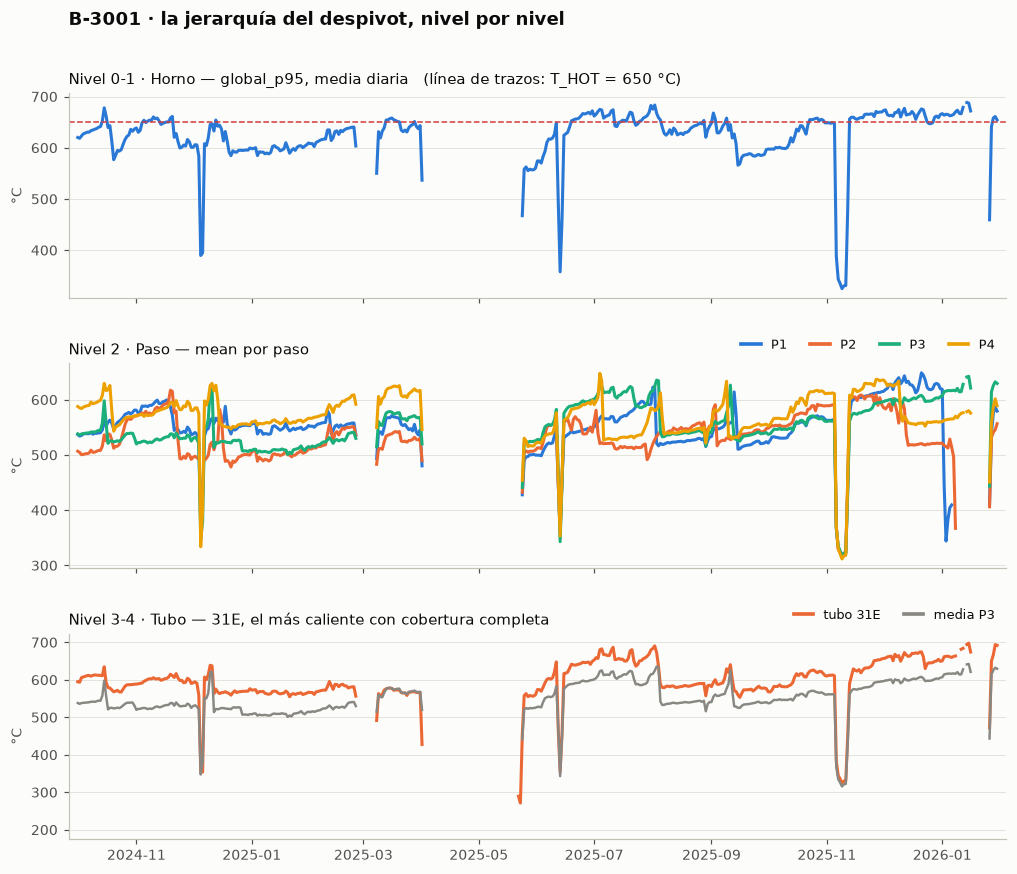

In [16]:
from matplotlib.lines import Line2D

def leyenda(ax, pares):
    """Leyenda de una fila, sin marco, alineada a la derecha del título del panel."""
    ax.legend(handles=[Line2D([], [], color=c, lw=2.4, label=l) for l, c in pares],
              loc="lower right", bbox_to_anchor=(1, 1.0), ncol=len(pares),
              frameon=False, fontsize=8.5, handlelength=1.5, columnspacing=1.8)

# --- la jerarquía, de arriba hacia abajo, en la ventana de análisis ---
d3 = nivel3[nivel3.run == 1].set_index("ts")
d2 = nivel2.pivot(index="ts", columns="paso", values="mean").reindex(d3.index)

# el tubo más caliente ENTRE LOS QUE TIENEN COBERTURA: si no, se elige uno cuyo sensor
# estuvo fuera de servicio media ventana y el panel queda vacío
cobertura = (r.groupby("tubo", observed=True).size()
             / nivel1.groupby("tubo", observed=True).size())
elegibles = cobertura[cobertura >= 0.7].index
tubo_top  = (r[r.tubo.isin(elegibles)]
             .groupby("tubo", observed=True).temperatura.quantile(0.95).idxmax())
paso_top  = TUBO_PASO[tubo_top]
d1 = (nivel1[nivel1.tubo == tubo_top].set_index("ts")[["temperatura"]].reindex(d3.index)
      .join(nivel2[nivel2.paso == paso_top].set_index("ts")[["mean"]]))

D = lambda s: s.resample("D").mean()

fig, axes = plt.subplots(3, 1, figsize=(11, 8.8), sharex=True,
                         gridspec_kw={"hspace": 0.32})

ax = axes[0]
ax.plot(D(d3.global_p95), color="#2a78d6", lw=2)
ax.axhline(T_HOT, color="#d03b3b", lw=1, ls="--")
ax.set_ylabel("°C")
ax.set_title(f"Nivel 0-1 · Horno — global_p95, media diaria   "
             f"(línea de trazos: T_HOT = {T_HOT:.0f} °C)", loc="left", fontsize=10)

ax = axes[1]
for p in PASOS:
    ax.plot(D(d2[p]), color=COLOR_PASO[p], lw=2)
ax.set_ylabel("°C")
ax.set_title("Nivel 2 · Paso — mean por paso", loc="left", fontsize=10)
leyenda(ax, [(p, COLOR_PASO[p]) for p in PASOS])

ax = axes[2]
ax.plot(D(d1.temperatura), color="#eb6834", lw=2)
ax.plot(D(d1["mean"]), color="#898781", lw=1.6)
ax.set_ylabel("°C")
ax.set_title(f"Nivel 3-4 · Tubo — {tubo_top}, el más caliente con cobertura completa",
             loc="left", fontsize=10)
leyenda(ax, [(f"tubo {tubo_top}", "#eb6834"), (f"media {paso_top}", "#898781")])

for a in axes:
    a.grid(axis="x", alpha=0)
    a.margins(x=0.01)
fig.suptitle("B-3001 · la jerarquía del despivot, nivel por nivel", x=0.125, ha="left",
             fontsize=12, fontweight="bold", y=0.965)
plt.savefig(REPORTES / "fig_jerarquia.png", dpi=150, bbox_inches="tight", facecolor=SUP)
plt.show()

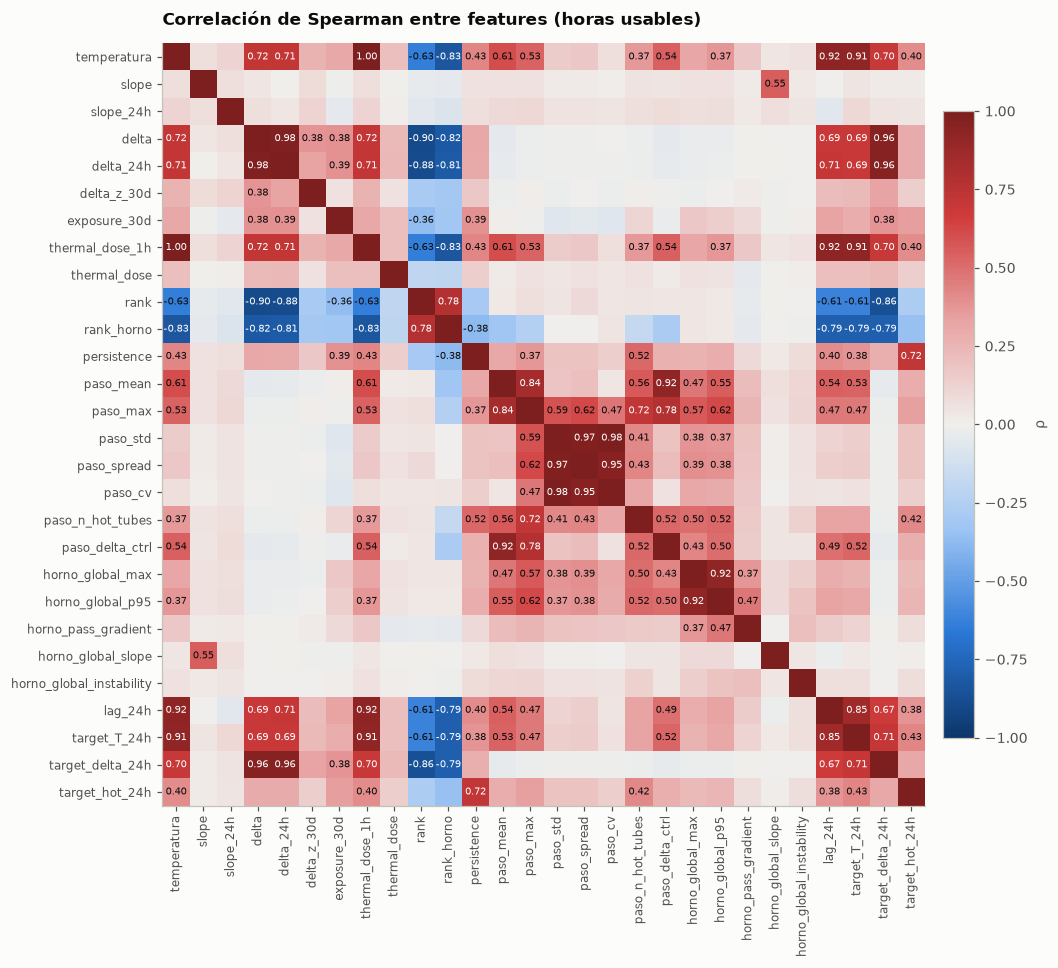


--- PREDICCIÓN · T a t+24 h ---
temperatura         0.915
thermal_dose_1h     0.915
lag_24h             0.853
rank_horno         -0.785
target_delta_24h    0.711
delta_24h           0.693

--- PREDICCIÓN · delta a t+24 h ---
delta           0.957
delta_24h       0.956
rank           -0.864
rank_horno     -0.788
target_T_24h    0.711
temperatura     0.696

--- CLASIFICACIÓN · hot a t+24 h (rank-biserial, prevalencia 6.5%) ---
persistence         0.724
target_T_24h        0.426
paso_n_hot_tubes    0.417
temperatura         0.399
thermal_dose_1h     0.399
lag_24h             0.382

--- RIESGO · daño instantáneo ---
temperatura     1.000
lag_24h         0.924
target_T_24h    0.915
rank_horno     -0.828
delta           0.717
delta_24h       0.715


In [17]:
# --- correlaciones (Spearman, solo horas usables, muestreadas) ---
FEATS = ["temperatura","slope","slope_24h","delta","delta_24h","delta_z_30d",
         "exposure_30d","thermal_dose_1h","thermal_dose","rank","rank_horno","persistence",
         "paso_mean","paso_max","paso_std","paso_spread","paso_cv","paso_n_hot_tubes",
         "paso_delta_ctrl","horno_global_max","horno_global_p95","horno_pass_gradient",
         "horno_global_slope","horno_global_instability","lag_24h","target_T_24h",
         "target_delta_24h","target_hot_24h"]

d = r.dropna(subset=["target_T_24h"])
d = d.sample(min(150_000, len(d)), random_state=0)
corr = d[FEATS].corr(method="spearman")
corr.round(3).to_csv(OUT_CORR)

fig, ax = plt.subplots(figsize=(10.5, 9))
im = ax.imshow(corr.values, cmap=CMAP_DIV, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr)), corr.columns, fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        if abs(v) >= 0.35 and i != j:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                    color="#ffffff" if abs(v) > 0.65 else TINTA)
ax.grid(False)
ax.set_title("Correlación de Spearman entre features (horas usables)",
             loc="left", fontsize=11, fontweight="bold", pad=12)
plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02, label="ρ")
plt.savefig(REPORTES / "fig_correlaciones_v2.png", dpi=150, bbox_inches="tight", facecolor=SUP)
plt.show()

for tgt, lbl in [("target_T_24h", "PREDICCIÓN · T a t+24 h"),
                 ("target_delta_24h", "PREDICCIÓN · delta a t+24 h"),
                 ("target_hot_24h", f"CLASIFICACIÓN · hot a t+24 h "
                                    f"(rank-biserial, prevalencia {d.target_hot_24h.mean()*100:.1f}%)"),
                 ("thermal_dose_1h", "RIESGO · daño instantáneo")]:
    print(f"\n--- {lbl} ---")
    print(corr[tgt].drop(tgt).sort_values(key=abs, ascending=False).head(6).round(3).to_string())

## 15. Exportación

Cinco archivos. Las tres tablas por nivel sirven para analizar cada escala por separado sin
arrastrar 46 columnas; `panel` es el dataset de entrenamiento; `b3001_largo` es el despivot
crudo del histórico completo, la materia prima para recalcular todo con otros parámetros.

In [18]:
salidas = [
    (OUT_LARGO, largo,  "despivot crudo, histórico completo (Nivel 3-4)"),
    (OUT_TUBO,  nivel1, "Nivel 1 · tubo"),
    (OUT_PASO,  nivel2, "Nivel 2 · paso"),
    (OUT_HORNO, nivel3, "Nivel 3 · horno"),
    (OUT_PANEL, panel,  "panel unido · dataset de modelado"),
]
for ruta, df, desc in salidas:
    df.to_parquet(ruta, compression="zstd", index=False)
    print(f"{ruta.name:<32} {df.shape[0]:>10,} x {df.shape[1]:>3}  "
          f"{ruta.stat().st_size/1e6:>7.1f} MB   {desc}")

b3001_largo.parquet               3,714,048 x  15     15.7 MB   despivot crudo, histórico completo (Nivel 3-4)
b3001_nivel1_tubo.parquet           280,296 x  37     14.3 MB   Nivel 1 · tubo
b3001_nivel2_paso.parquet            46,716 x  16      2.8 MB   Nivel 2 · paso
b3001_nivel3_horno.parquet           11,679 x  16      0.7 MB   Nivel 3 · horno
b3001_panel.parquet                 280,296 x  64     19.8 MB   panel unido · dataset de modelado


---

### Notas de uso

**Filtrado**

- Filtrar siempre por `run == 1` **y** `valido == 1`. Lo primero descarta las detenciones
  (enfriamiento sin fuego ni flujo: física distinta); lo segundo, los termopares fallados.
  Entrenar sin el segundo filtro le enseña al modelo que un tubo puede estar a 250 °C con el
  horno encendido.
- `sensor_health_30d` sirve como peso de muestra o como corte: un tubo con salud <0.5 aporta
  features de ventana móvil calculadas sobre la mitad de los datos.

**Validación**

- Temporal, nunca aleatoria. Con `lag_24h` y correlaciones de 0.9+, un split aleatorio filtra
  el futuro y da métricas irreales. Entrenar hasta una fecha de corte y evaluar después.
- Baseline obligatorio: persistencia (`lag_24h` como predicción de `target_T_24h`). Si el
  modelo no lo supera, no aprendió nada del proceso.
- Con `tubo` como categórica, validar también *por tubo*: un modelo puede tener buen MAE
  global y fallar sistemáticamente en los 2-3 tubos que importan.

**Colinealidad y fugas** (ρ de Spearman medidos sobre las horas usables, celda 14)

- **`thermal_dose_1h` ↔ `temperatura`: ρ = 1.00.** El primero es función monótona del segundo
  por construcción. Nunca los dos juntos como predictores.
- **Bloque de dispersión del paso:** `paso_std` ↔ `paso_cv` 0.98, `paso_std` ↔ `paso_spread`
  0.97, `paso_spread` ↔ `paso_cv` 0.95. Son la misma señal en tres escalas: elegir una.
  `spread` es la más interpretable en planta (°C entre el tubo más caliente y el más frío);
  `cv` es la única comparable entre pasos a distinta temperatura.
- **Bloque de nivel térmico:** `temperatura` ↔ `lag_24h` 0.92, `delta` ↔ `delta_24h` 0.98,
  `paso_mean` ↔ `paso_delta_ctrl` 0.92, `horno_global_max` ↔ `horno_global_p95` 0.92. Un
  representante por bloque para modelos lineales o para SHAP; los de árboles lo toleran.
- `paso_p95` ≈ `paso_max` con 6 tubos (percentil interpolado sobre 3-6 valores). Elegir uno.
- `delta` ya tiene descontado el nivel del paso: usarlo *con* `paso_mean` es lo correcto
  (separa "el horno está caliente" de "este tubo está caliente"), usarlo con `temperatura`
  es casi redundante.
- Las que **sí aportan información independiente** (|ρ| < 0.3 contra casi todo lo demás):
  `slope_24h`, `thermal_dose`, `horno_global_instability`, `horno_pass_gradient` y
  `sensor_health_30d`. Son las primeras candidatas a mirar cuando el modelo se estanca en el
  baseline de persistencia.

**Qué predice cada objetivo** (rankings de la celda 14)

- `target_T_24h` lo domina el nivel térmico actual (`temperatura` 0.92, `lag_24h` 0.85): es el
  objetivo donde el baseline de persistencia es más difícil de superar.
- `target_delta_24h` lo domina `delta` (0.96) y `delta_24h` (0.96). Mismo problema, pero sobre
  la señal ya descontada del modo común: es el objetivo más informativo de los tres para
  mantenimiento, porque un error de 10 °C en `delta` importa mucho más que 10 °C en `T`.
- `target_hot_24h` lo domina **`persistence` (0.72), muy por encima de `temperatura` (0.40)**:
  para anticipar si un tubo estará caliente en 24 h pesa más *cuánto lleva caliente* que *cuán
  caliente está ahora*. Le sigue `paso_n_hot_tubes` (0.42), también por encima de la
  temperatura del propio tubo: el estado del paso anticipa mejor que el estado individual. Es
  el argumento más fuerte a favor de las features de persistencia y de las de nivel 2.

**Acumuladas**

- `thermal_dose`, `exposure` y sus versiones globales son monótonas crecientes y arrastran el
  histórico desde 2008. Son **estado de criticidad inicial**, no señal hora a hora: en un
  modelo temporal generan tendencia espuria. Para riesgo/vida remanente usar `thermal_dose`
  como nivel al inicio de la ventana y `thermal_dose_30d` como ritmo.

**Interpretación de los tres niveles**

- Un `slope` alto con `paso_spread` bajo y `global_slope` alto es una **maniobra de
  operación**: sube todo el horno.
- Un `slope` alto con `paso_spread` creciendo y `global_slope` plano es un **problema de
  tubo**: coquización, obstrucción o quemador desalineado.
- `pass_gradient` alto y sostenido con `critical_pass_persistence` de cientos de horas es un
  **desbalance de distribución**, no un tubo: se corrige con fuego o con flujo, no cambiando
  un tubo.